In [1]:
import matplotlib 
import matplotlib.lines as lines
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [37]:
# Input size columns
input_size_seconds = [2, 4, 8, 16, 32, 64]
input_size_count = [12000, 25000, 49000, 98000, 197000, 393000]

# VRAM usage columns (GiB)
vram_cnn = [0.085, 0.142, 0.257, 0.492, 0.953, 1.875]
vram_cnn_vit = [0.195, 0.334, 0.629, 1.196, 2.349, 4.646]

# AUROC performance columns (%)
auroc_cnn = [86.7, 86.1, 84.6, 83.8, 82.4, 81.1]
auroc_cnn_vit = [87.7, 86.9, 85.6, 85.0, 84.1, 82.8]
auroc_delta = [1.0, 0.8, 1.0, 1.2, 1.7, 1.7]

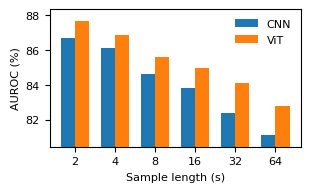

In [38]:
fig, ax = plt.subplots(figsize=(8/2.54, 5/2.54))
x = np.arange(len(input_size_seconds))
width = 0.35
ax.bar(x-width/2, auroc_cnn, width, label="CNN")
ax.bar(x+width/2, auroc_cnn_vit, width, label="ViT")
lower, upper = np.min([auroc_cnn, auroc_cnn_vit]), np.max([auroc_cnn, auroc_cnn_vit])
delta = upper - lower
ax.set_ylim(lower-0.1*delta, upper+0.1*delta)
ax.set_xticks(x, input_size_seconds)
ax.legend(frameon=False)
ax.set_xlabel("Sample length (s)")
ax.set_ylabel("AUROC (%)")
fig.tight_layout()
fig.savefig("performance.png", dpi=300, bbox_inches="tight")

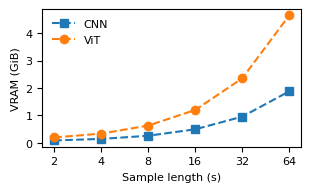

In [39]:
fig, ax = plt.subplots(figsize=(8/2.54, 5/2.54))
x = np.arange(len(input_size_seconds))
ax.plot(x, vram_cnn, ls="--", marker="s", label="CNN")
ax.plot(x, vram_cnn_vit, ls="--", marker="o", label="ViT")
ax.set_xticks(x, input_size_seconds)
ax.legend(frameon=False)
ax.set_xlabel("Sample length (s)")
ax.set_ylabel("VRAM (GiB)")
fig.tight_layout()
fig.savefig("vram_seconds.png", dpi=300, bbox_inches="tight")

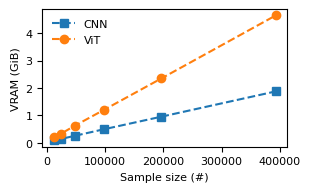

In [40]:
fig, ax = plt.subplots(figsize=(8/2.54, 5/2.54))
ax.plot(input_size_count, vram_cnn, ls="--", marker="s", label="CNN")
ax.plot(input_size_count, vram_cnn_vit, ls="--", marker="o", label="ViT")
ax.legend(frameon=False)
ax.set_xlabel("Sample size (#)")
ax.set_ylabel("VRAM (GiB)")
fig.tight_layout()
fig.savefig("vram_size.png", dpi=300, bbox_inches="tight")